<a href="https://colab.research.google.com/github/Boran-Sert/SoftITO_Projler/blob/master/Python/23.09.2026_Ders_i%C3%A7i_karar_a%C4%9Fac%C4%B1_%C3%A7al%C4%B1%C5%9Fmas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram,linkage

In [34]:
df=pd.read_csv("data.csv")
print(f"veri boyutu:{df.shape}")
df.info()
print(df['gender'].unique())


veri boyutu:(5001, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB
['Male' 'Female']


In [4]:
df.isnull().sum()

,0
long_hair,0
forehead_width_cm,0
forehead_height_cm,0
nose_wide,0
nose_long,0
lips_thin,0
distance_nose_to_lip_long,0
gender,0


In [5]:
df.head(2)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female


In [15]:
import random
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,classification_report,ConfusionMatrixDisplay,RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder

In [30]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)

X = df.drop('gender', axis = 1)
y = df['gender']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
dt_grid= GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                      param_grid={
                          "criterion":["gini","entropy"],
                          "splitter":["best","random"],
                          "max_depth":[3,4,5,6,8,None],
                          "min_samples_leaf" :[1,2,5,10]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1)
dt_grid.fit(X_train,y_train)
dt=dt_grid.best_estimator_
print("En iyi parametre:", dt_grid.best_params_)
print(model.classes_)


En iyi parametre: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 5, 'splitter': 'best'}
[0 1]


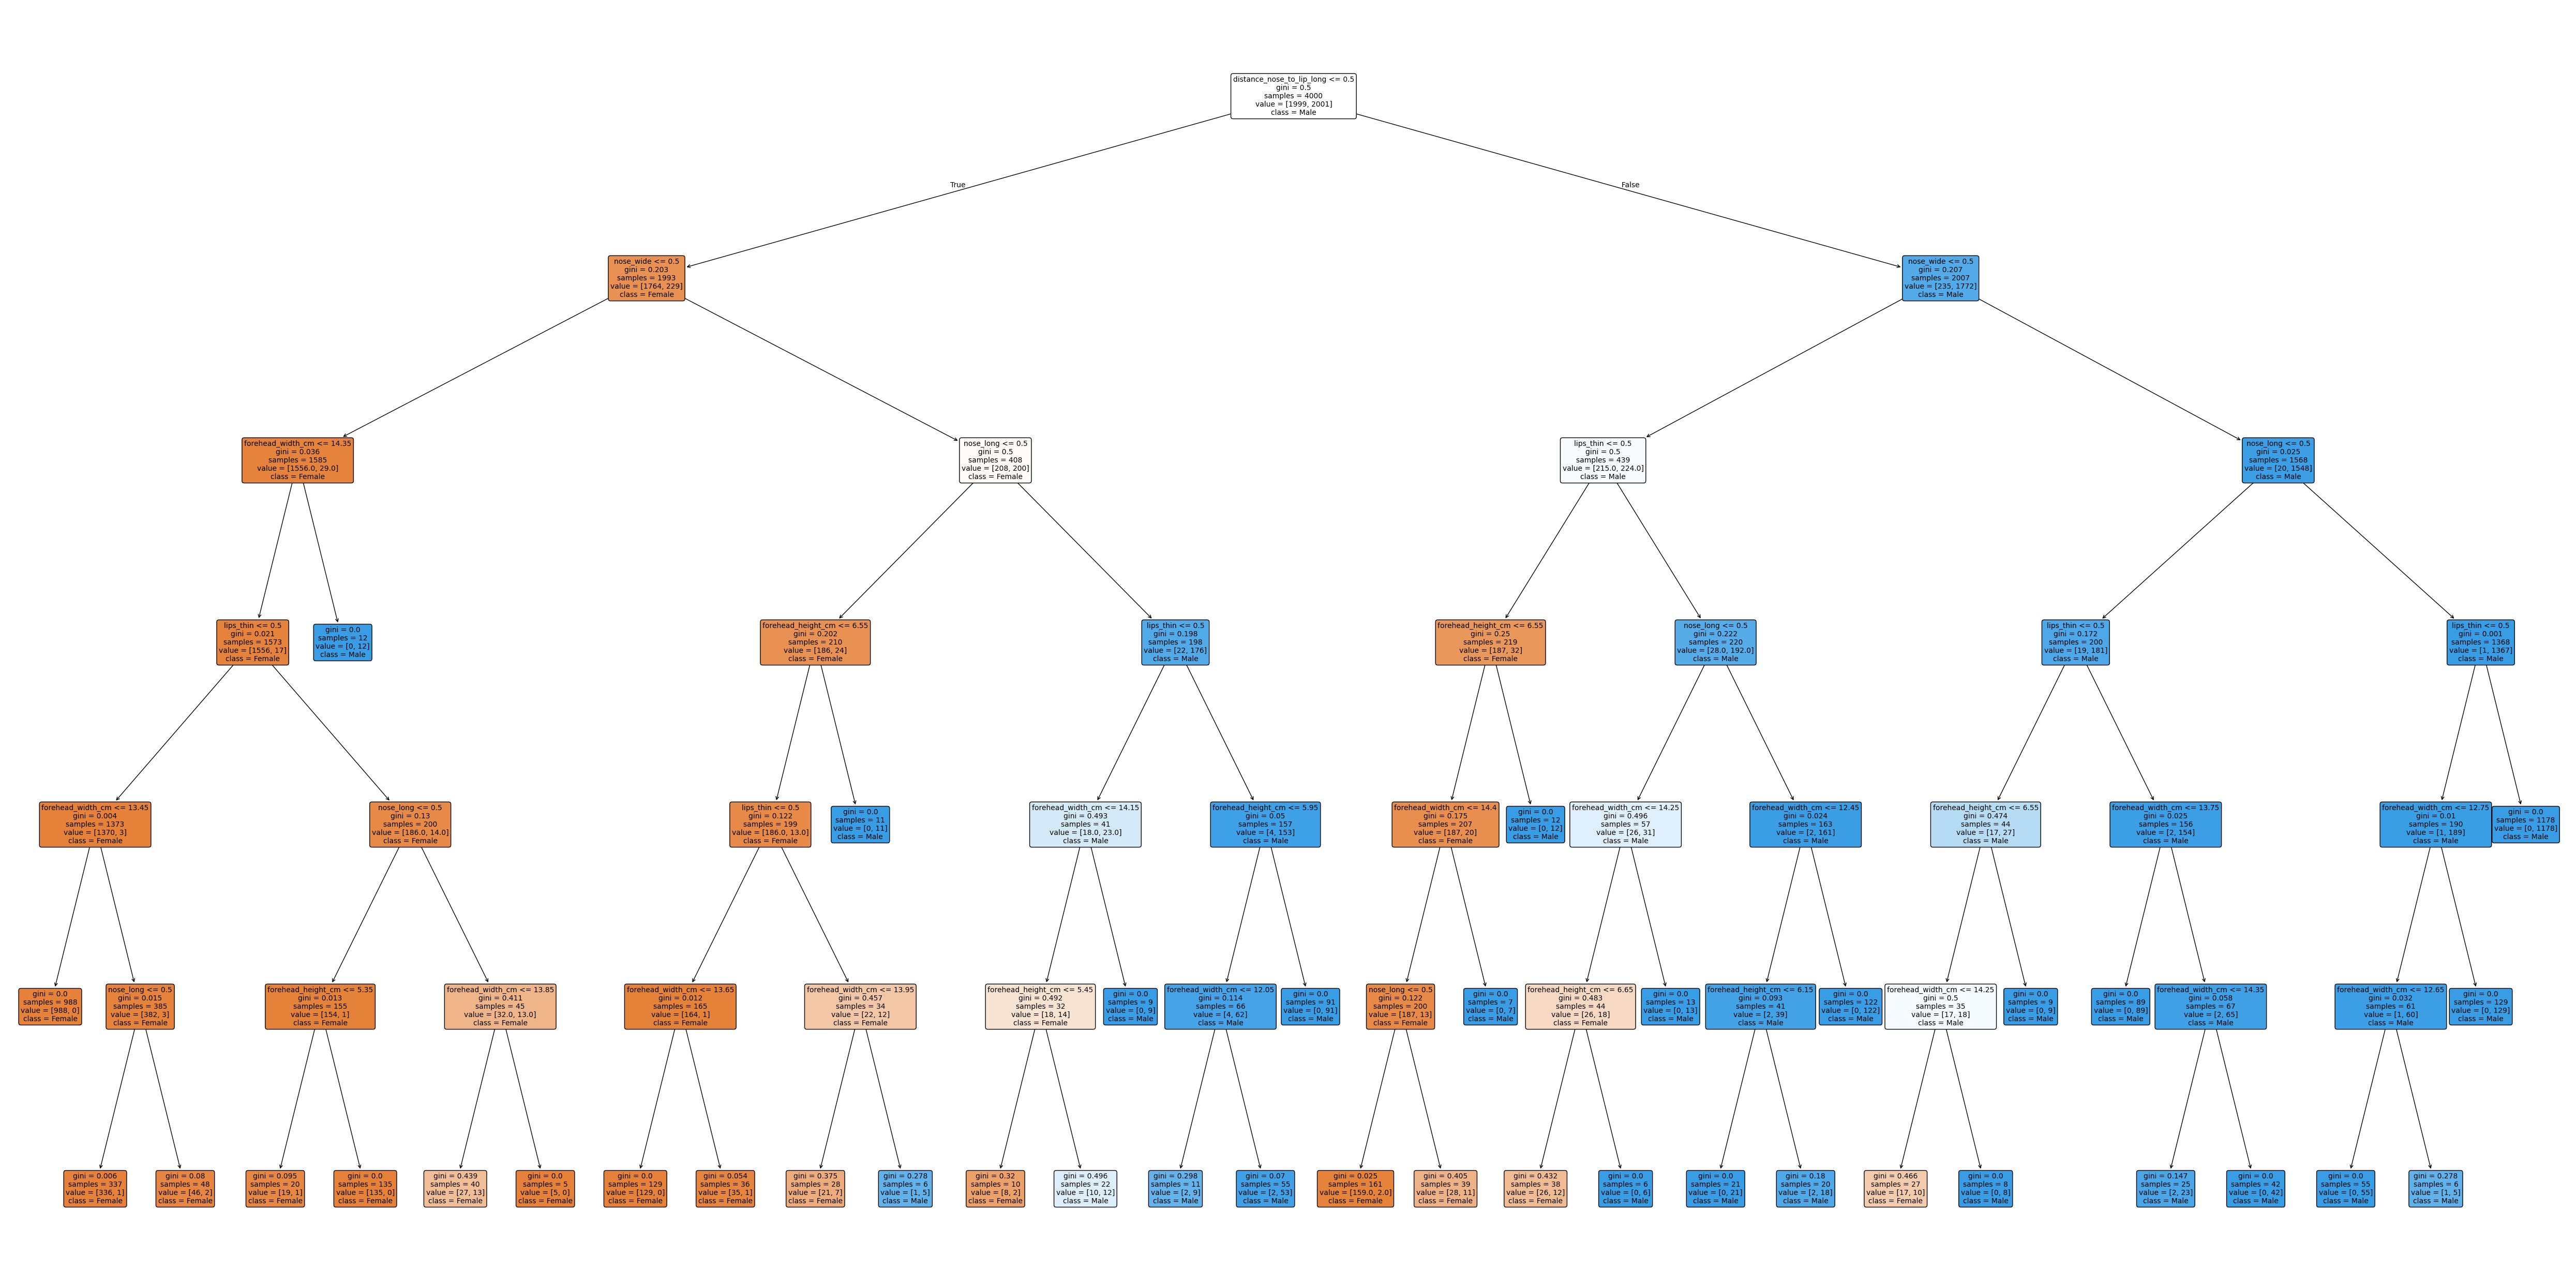

In [24]:
plt.figure(figsize=(64,32))
plot_tree(dt,
          feature_names=list(X.columns),
          class_names=['Female', 'Male'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier
rf_grid= GridSearchCV(RandomForestClassifier(random_state=SEED),
                      param_grid={
                          "n_estimators":[100,200],
                          "max_depth":[5,7],
                          "min_samples_leaf" :[1,2],
                          "min_samples_split":[2,5],
                          "max_features":["sqrt","log2"],
                          "criterion":["gini","entropy"],
                          "bootstrap":[True,False]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1,verbose =3)
rf_grid.fit(X_train,y_train)
rf=rf_grid.best_estimator_
print("En iyi parametre:", rf_grid.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
En iyi parametre: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [26]:
for name,model in [("Decision Tree" ,dt),("Random Forest",rf)]:
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    cv_scores=cross_val_score(model,X_train,y_train,cv=cv,scoring="accuracy")
    print(f"========{"Test"}========")
    print(f"Test doğruluğu:{accuracy_score(y_test,y_pred)}")
    print(f"Ortalama 5 katlı CV doğruluğu:{np.mean(cv_scores)}")

========Test========
Test doğruluğu:0.9660339660339661
Ortalama 5 katlı CV doğruluğu:0.9729999999999999
========Test========
Test doğruluğu:0.967032967032967
Ortalama 5 katlı CV doğruluğu:0.9782500000000001


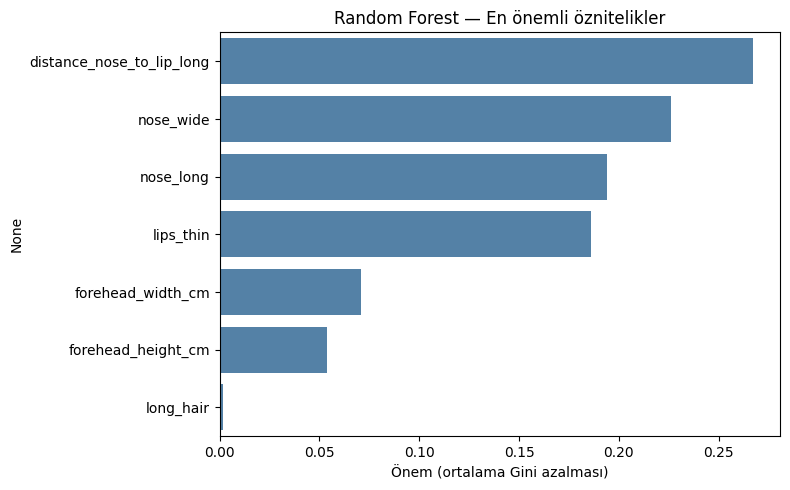

Grafikler kaydedildi: feature_importance.png


In [28]:
imp = pd.Series(rf.feature_importances_, index=X.columns).nlargest(7)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.xlabel("Önem (ortalama Gini azalması)")
plt.title("Random Forest — En önemli öznitelikler")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("Grafikler kaydedildi: feature_importance.png")